In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats

# **INPUT DATA DAN OLS**

In [13]:
# input data
df = pd.read_csv('/workspaces/TugasEVDA-MOLIN/Tugas molin/Tugas 1 - regresi/Sleep_health_and_lifestyle_dataset.csv') 


df_80 = df.sample(frac=0.8, random_state=42) # ambil 80% sesuai arahan
df_80.to_csv('Data1.csv', index=False) # bikin copy data 80%

sleep_duration = df_80['Sleep Duration'] # sleep duration sebagai x
stress_level = df_80['Stress Level'] # stress level sebagai y



In [14]:
# rumus regresi linear sederhana: y = B0 + B1*x
# menghitung B1 (slope)
B1 = np.cov(sleep_duration, stress_level)[0][1] / np.var(sleep_duration, ddof=1)
 
# Menghitung B0
B0 = np.mean(stress_level) - B1 * np.mean(sleep_duration)
print("Beta0 =", B0, "Beta1=", B1)


Beta0 = 18.301816122722848 Beta1= -1.8082599805957305


In [16]:
# mencetak taksiran persamaan regresi
# Menghitung array nilai prediksi Y
y_pred = B0 + (B1 * sleep_duration)
print(f"Y pred: {y_pred}")  
print(f"Persamaan regresi: y_pred = {B0:.4f} + {B1:.4f} * sleep duration")

Y pred: 329    2.931606
33     7.271430
15     7.452256
325    2.931606
57     7.452256
         ...   
321    3.112432
236    6.728952
207    4.378214
212    4.197388
295    7.452256
Name: Sleep Duration, Length: 299, dtype: float64
Persamaan regresi: y_pred = 18.3018 + -1.8083 * sleep duration


# **GOODNESS OF FIT**

In [17]:
#R^2 test
SST = np.sum((stress_level - np.mean(stress_level))**2)

SSE = np.sum((stress_level - y_pred)**2)

SSR = np.sum((y_pred - np.mean(stress_level))**2)

r_squared = 1 - (SSE / SST)

#ANOVA test

# menghitung Derajat Bebas (Degrees of Freedom / df)
n = len(stress_level) # Jumlah observasi/sampel data 80%
df_ssr = 1            # df regresi (karena hanya ada 1 variabel prediktor)
df_sse = n - 2        # df error

# 2. menghitung Mean Squares
MSR = SSR / df_ssr
MSE = SSE / df_sse

# 3. menghitung F-Statistic
F_stat = MSR / MSE

# 4. menghitung p-value dari distribusi F
p_value = stats.f.sf(F_stat, df_ssr, df_sse)

# print the goodness of fit (R^2) dan uji-F (ANOVA)
print(f"Goodness of fit (R^2): {r_squared:.4f}")
print(f"F-statistic (ANOVA): {F_stat:.4f}")
print(f"p-value: {p_value:.4e}")





Goodness of fit (R^2): 0.6629
F-statistic (ANOVA): 584.0853
p-value: 4.1966e-72


# **PLOTTING**

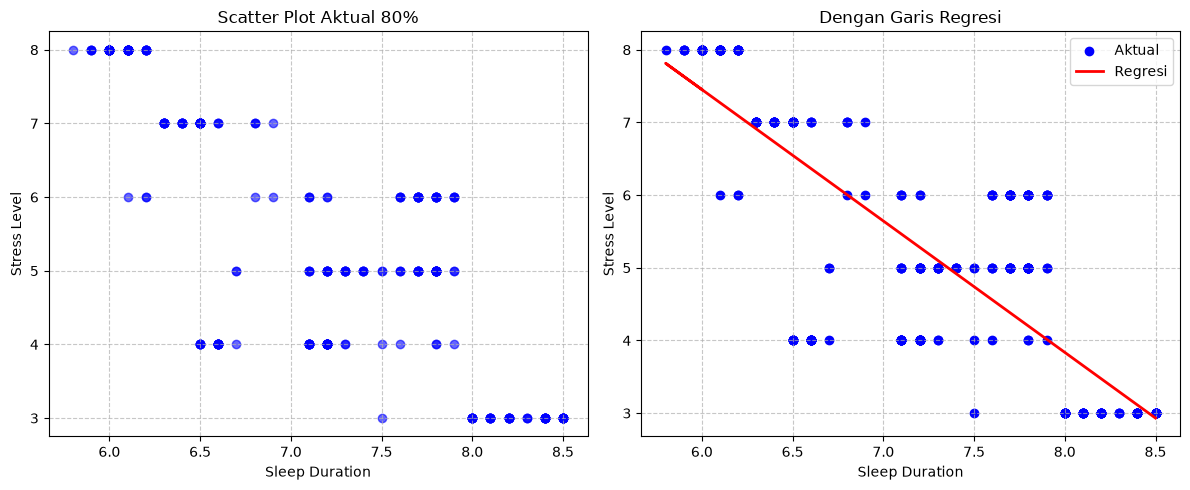

In [18]:
# akan dibuat 2 graph perbandingan, scatterplot dan scatterplot dengan garis linear
# scatterplot biasa:
plt.figure(figsize=(12, 5)) # buat canvas 12 inci pada x, 5 inci pada 5
plt.subplot(1, 2, 1) 

plt.scatter(sleep_duration, stress_level, color='blue', alpha=0.6)
plt.xlabel("Sleep Duration")
plt.ylabel("Stress Level")
plt.title("Scatter Plot Aktual 80%")
plt.grid(True, linestyle='--', alpha=0.7)

# scatterplot dengan garis linear
plt.subplot(1, 2, 2) 

y_pred = B0 + B1 * sleep_duration
plt.scatter(sleep_duration, stress_level, color='blue', label='Aktual')
plt.plot(sleep_duration, y_pred, color='red', linewidth=2, label='Regresi')

plt.xlabel("Sleep Duration")
plt.ylabel("Stress Level")
plt.title("Dengan Garis Regresi")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)

# merapikan jarak antar graph agar tidak bertumpuk
plt.tight_layout()


plt.show()